In [30]:
import os
import sys

# Add the parent directory to sys.path to allow imports from src
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch

from src.train_word2vec import Word2VecTimeSliceConfig, train_word2vec_time_slices
from src.vizz import plot_norm_trajectory, plot_tsne_trajectory, load_wordlist

## Configuration

Train a classic Word2Vec model (skip-gram with negative sampling) in pure PyTorch.
We train one model per year (time slice) and report semantic drift across years.

In [31]:
# Years in the dataset correspond to PMI files indexed from 0..(T-1): wordPairPMI_0.csv, wordPairPMI_1.csv, ...
start_year = 1990
end_year = 1991  # bump to 2016 for full run if you have time/resources
years = list(range(start_year, end_year + 1))

# These PMI CSVs are large; we reservoir-sample a fixed number of positive pairs per year.
pmi_csv_pattern = '../data/data_other_embeddings/wordPairPMI_{t_idx}.csv'

cfg = Word2VecTimeSliceConfig(
    vocab_size=20936,
    embedding_dim=100,
    num_negatives=10,
    batch_size=4096,
    epochs_per_year=1,
    lr=2e-3,
    unigram_power=0.75,
    min_pmi=0.0,              # keep only positive PMI pairs
    max_pairs_per_year=50_000,  # increase for better quality (memory/time tradeoff)
    warm_start=True,
    device='auto',
)

save_dir = '../results/sgns_word2vec'
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Device: cpu


## Training

This trains an `nn.Module` SGNS Word2Vec model per year, warm-starting from the previous year's weights.
It saves yearly checkpoints in `results/sgns_word2vec/` and returns embeddings for downstream analysis.

In [32]:
os.makedirs(save_dir, exist_ok=True)

w2v_result = train_word2vec_time_slices(
    years=years,
    pmi_csv_pattern=pmi_csv_pattern,
    save_dir=save_dir,
    cfg=cfg,
 )

print('Finished training.')
if w2v_result.mean_drift:
    for y0, y1, d in zip(w2v_result.years[:-1], w2v_result.years[1:], w2v_result.mean_drift):
        print(f"Mean drift {y0}->{y1}: {d:.4f}")

Finished training.
Mean drift 1990->1991: 0.2260


## Visualization & Dynamics

We reuse the existing plotting helpers to visualize dynamics of the learned Word2Vec embeddings over time.

In [34]:
U_list = w2v_result.embeddings
time_points = w2v_result.years
print(f"Got embeddings for {len(time_points)} time points")

Got embeddings for 2 time points


In [40]:
# Load word list to map indices to words (matches the PMI indices used for training)
wordlist_path = '../data/data_other_embeddings/wordIDHash.csv'
wordlist, word2id = load_wordlist(wordlist_path)

if not wordlist:
    raise FileNotFoundError(f"Wordlist not found at {wordlist_path}")

print(f"Loaded {len(wordlist)} words from wordlist.")

Loaded 20936 words from wordlist.


### Word Norm Trajectories
Visualize how the "significance" (norm) of words changes over time.

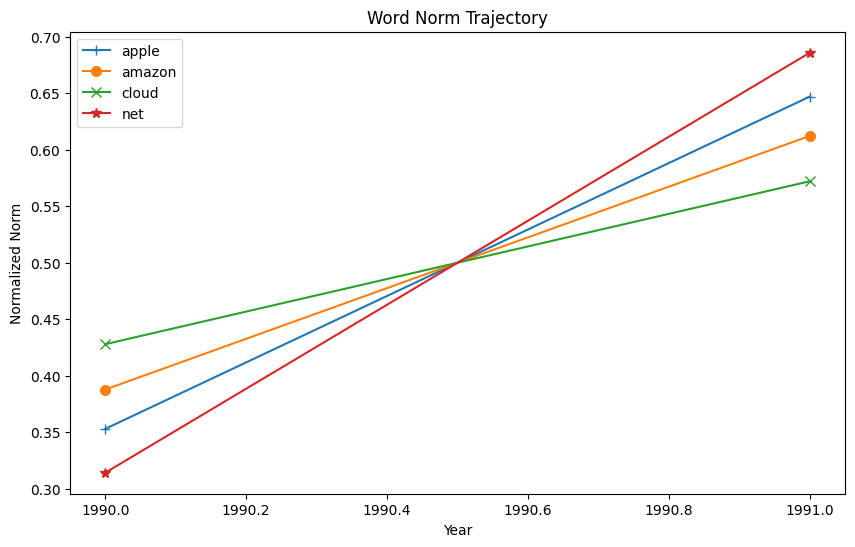

In [41]:
# Select words to visualize
target_words = ['apple', 'amazon', 'cloud', 'net']
valid_words = [w for w in target_words if w in word2id]

if valid_words:
    plot_norm_trajectory(U_list, valid_words, word2id, time_points)
else:
    print('None of the target words found in vocabulary.')

### t-SNE Trajectory
Visualize the semantic shift of a specific word in 2D space.

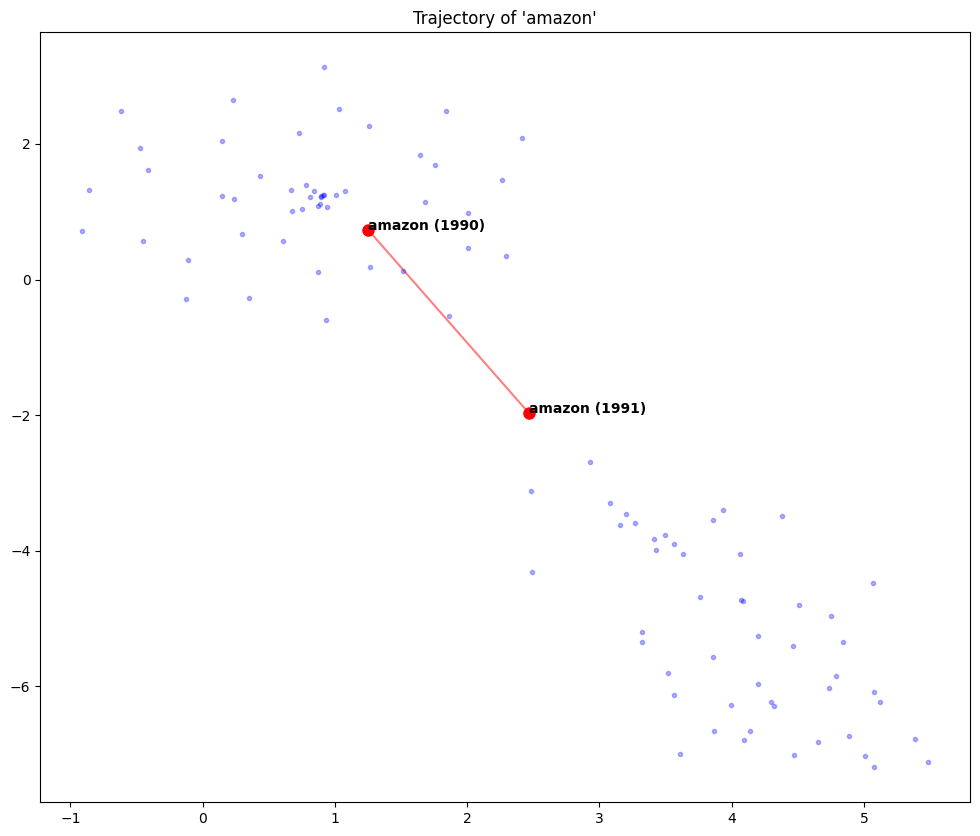

In [ ]:
target_word = 'amazon'

if target_word in word2id:
    plot_tsne_trajectory(U_list, target_word, word2id, wordlist, time_points)
else:
    print(f"Word '{target_word}' not found in vocabulary.")